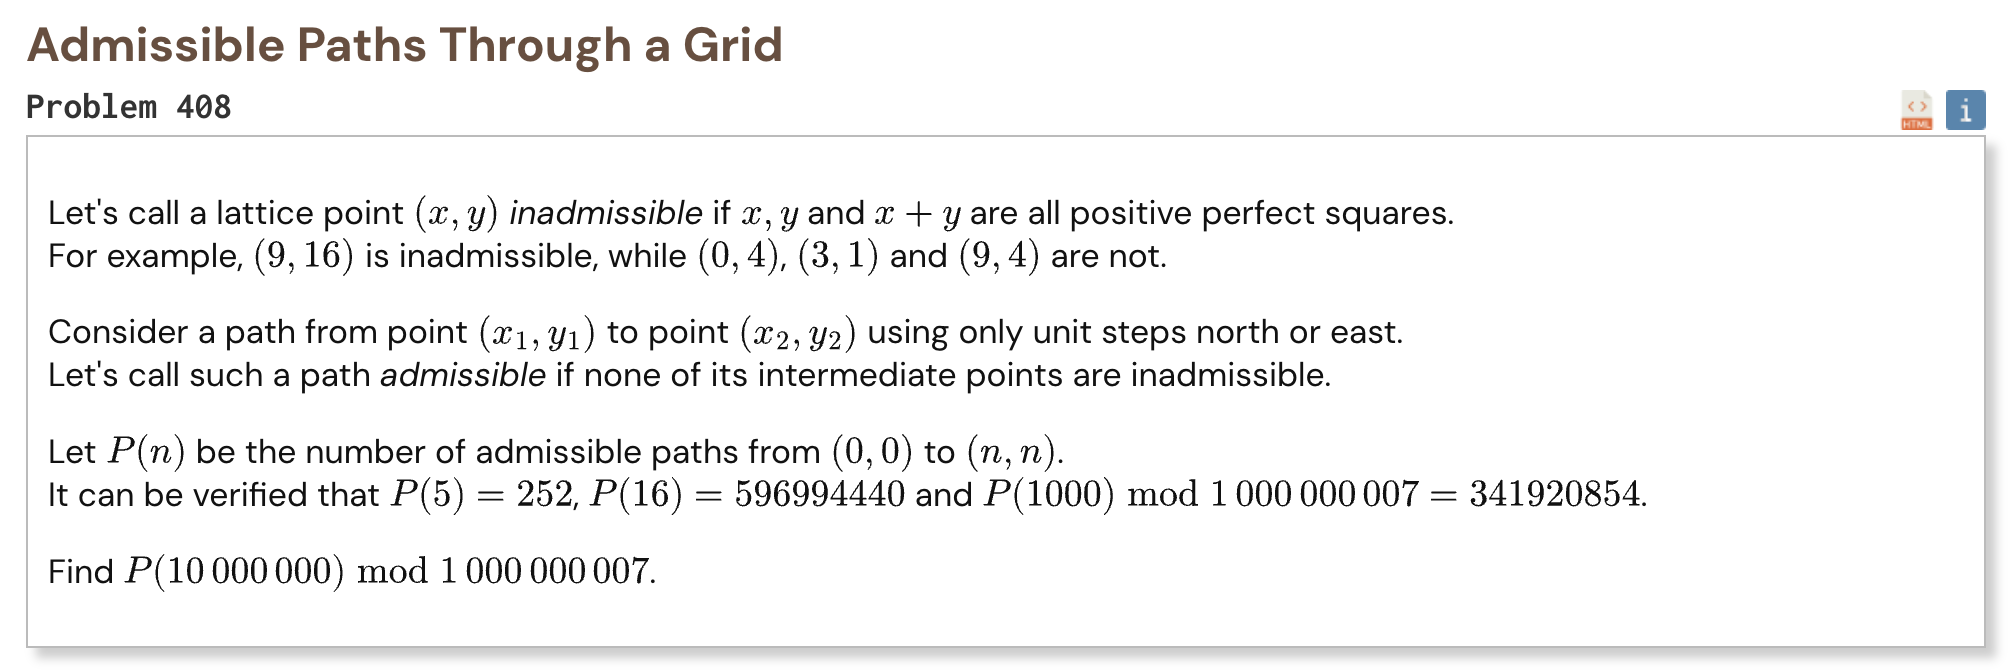

## Initial approach

-   generate every forbidden point using primitive right triangles and their scaled copies
-   sort the forbidden points in the order that a path can reach them
-   precompute factorials so the number of paths between two points is found quickly
-   count paths reaching each forbidden point without touching an earlier forbidden point
-   subtract every path that reaches a forbidden point from the total
-   use array to store the large factorial tables with much less memory
-   take every calculation modulo the required prime

In [1]:
%%time

from array import array
from math import gcd, isqrt

MOD = 1_000_000_007

def find_forbidden_points(limit):
    max_leg = isqrt(limit)
    max_hypotenuse = isqrt(2 * limit)
    points = []
    m = 2

    while m * m + 1 <= max_hypotenuse:
        for n in range(1, m):
            if (m - n) % 2 == 0:
                continue
            if gcd(m, n) != 1:
                continue

            first = m * m - n * n
            second = 2 * m * n
            max_scale = min(max_leg // first, max_leg // second)

            for scale in range(1, max_scale + 1):
                x = (scale * first) ** 2
                y = (scale * second) ** 2
                points.append((x, y))
                points.append((y, x))

        m += 1

    points.sort(key=lambda point: (point[0] + point[1], point[0]))
    return points

def count_admissible_paths(limit):
    maximum = 2 * limit

    factorial = array("I", [1]) * (maximum + 1)
    inverse_factorial = array("I", [1]) * (maximum + 1)

    for value in range(1, maximum + 1):
        factorial[value] = factorial[value - 1] * value % MOD

    inverse_factorial[maximum] = pow(
        factorial[maximum],
        MOD - 2,
        MOD
    )

    for value in range(maximum, 0, -1):
        inverse_factorial[value - 1] = (
            inverse_factorial[value] * value % MOD
        )

    def paths(x, y):
        result = factorial[x + y]
        result = result * inverse_factorial[x] % MOD
        result = result * inverse_factorial[y] % MOD
        return result

    points = find_forbidden_points(limit)
    points.append((limit, limit))
    ways = []

    for index, (x, y) in enumerate(points):
        count = paths(x, y)

        for previous in range(index):
            old_x, old_y = points[previous]

            if old_x <= x and old_y <= y:
                blocked = ways[previous]
                blocked *= paths(x - old_x, y - old_y)
                count = (count - blocked) % MOD

        ways.append(count)

    return ways[-1]

result = count_admissible_paths(10_000_000)
print("Result:", result)

Result: 299742733
CPU times: user 15.6 s, sys: 134 ms, total: 15.8 s
Wall time: 15.8 s
